In [1]:
# Dépendances
%pip install dvc[gdrive] pandas numpy matplotlib seaborn -q

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style global des figures
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

# Chargement
df = pd.read_csv('/content/drive/MyDrive/dvc-storage/files/md5/b3/066905e9eb4d477453d473dbf20c02',
                 encoding='latin-1')

print(f"Dimensions : {df.shape}")
print(f"Colonnes : {list(df.columns)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/3

In [2]:
# Types et valeurs manquantes
print("=== TYPES & VALEURS MANQUANTES ===")
info = pd.DataFrame({
    'Type': df.dtypes,
    'Nulls': df.isnull().sum(),
    'Null%': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique': df.nunique()
})
print(info)

# Doublons
print(f"\nDoublons : {df.duplicated().sum()}")

# Aperçu
df.head(3)

=== TYPES & VALEURS MANQUANTES ===
                  Type  Nulls  Null%  Unique
Row ID           int64      0    0.0    9994
Order ID        object      0    0.0    5009
Order Date      object      0    0.0    1237
Ship Date       object      0    0.0    1334
Ship Mode       object      0    0.0       4
Customer ID     object      0    0.0     793
Customer Name   object      0    0.0     793
Segment         object      0    0.0       3
Country         object      0    0.0       1
City            object      0    0.0     531
State           object      0    0.0      49
Postal Code      int64      0    0.0     631
Region          object      0    0.0       4
Product ID      object      0    0.0    1862
Category        object      0    0.0       3
Sub-Category    object      0    0.0      17
Product Name    object      0    0.0    1850
Sales          float64      0    0.0    5825
Quantity         int64      0    0.0      14
Discount       float64      0    0.0      12
Profit         float

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


=== VARIABLE CIBLE : Sales ===
count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64


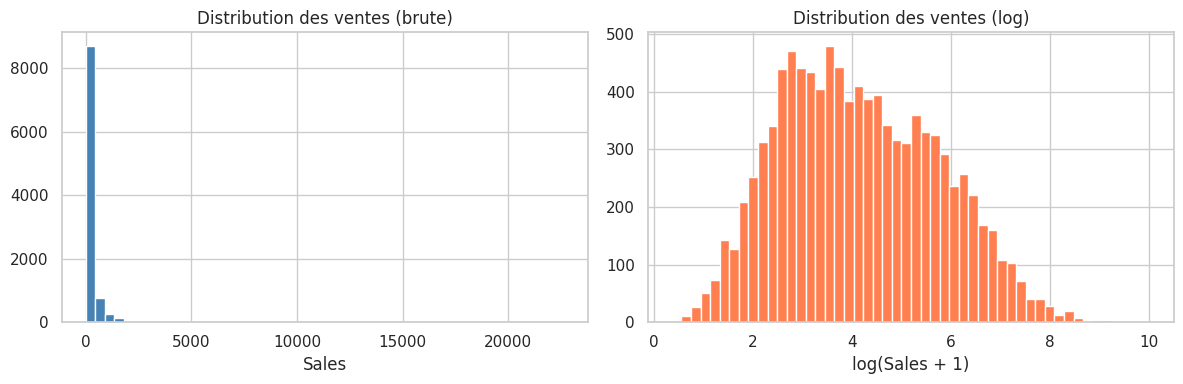

In [3]:
# La variable cible : Sales (prédiction du chiffre de ventes)
print("=== VARIABLE CIBLE : Sales ===")
print(df['Sales'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution brute
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des ventes (brute)')
axes[0].set_xlabel('Sales')

# Distribution log (souvent plus utile pour la régression)
axes[1].hist(np.log1p(df['Sales']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution des ventes (log)')
axes[1].set_xlabel('log(Sales + 1)')

plt.tight_layout()
plt.savefig('fig1_sales_distribution.png', dpi=150)
plt.show()

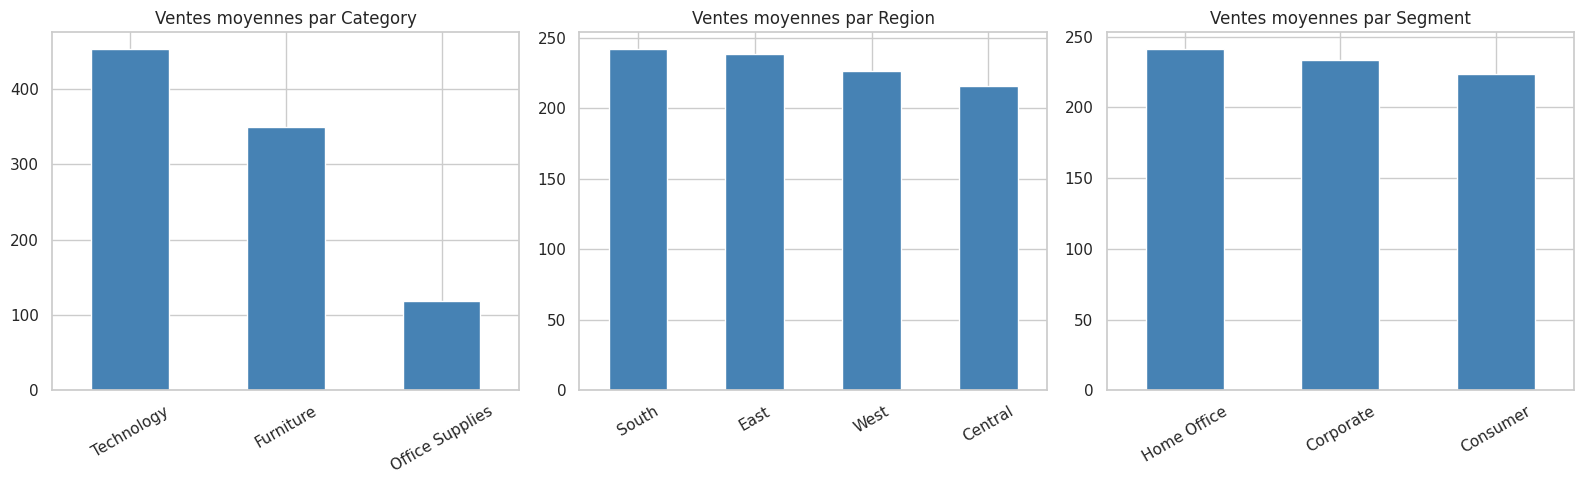

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Category', 'Region', 'Segment']):
    means = df.groupby(col)['Sales'].mean().sort_values(ascending=False)
    means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Ventes moyennes par {col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig2_sales_by_category.png', dpi=150)
plt.show()

Colonnes numériques : ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']


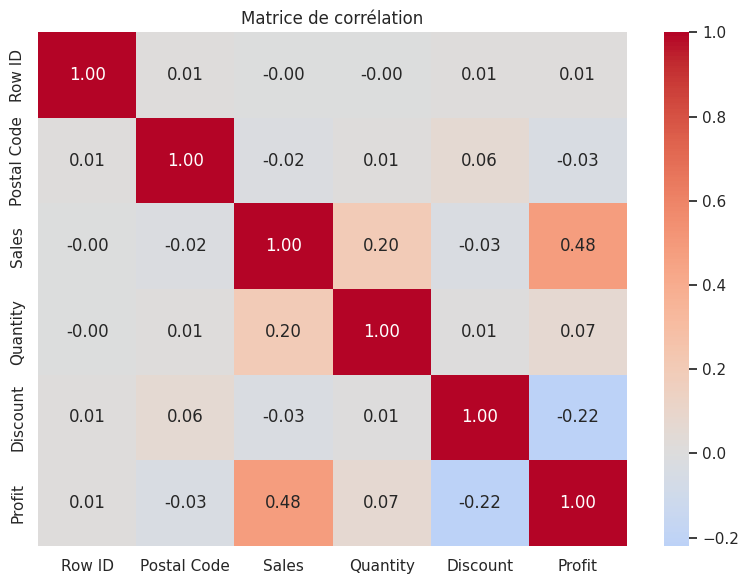

In [5]:
# Sélectionne uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Colonnes numériques : {numeric_cols}")

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', dpi=150)
plt.show()

In [7]:
df['is_profitable'] = (df['Profit'] > 0).astype(int)
# 1 = transaction profitable
# 0 = transaction à perte ou nulle
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,is_profitable
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,1
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,1
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,1


/tmp/ipykernel_4183/1783917785.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_rate = df.groupby('Category').apply(


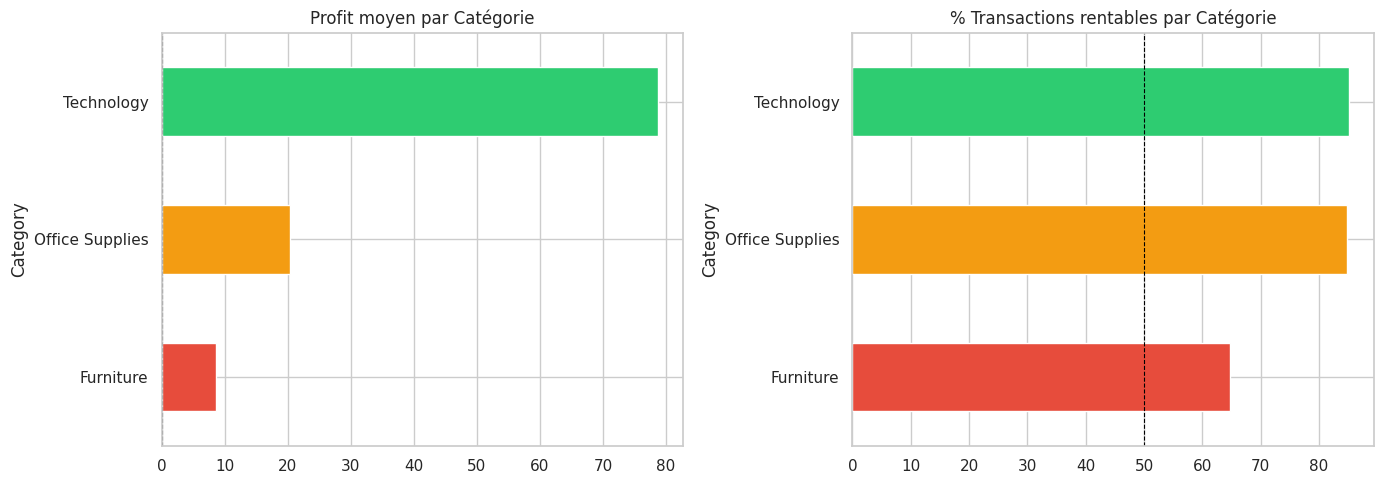

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit moyen par catégorie
cat_profit = df.groupby('Category')['Profit'].mean().sort_values()
cat_profit.plot(kind='barh', ax=axes[0], color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Profit moyen par Catégorie')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

# % de transactions rentables par catégorie
cat_rate = df.groupby('Category').apply(
    lambda x: (x['Profit'] > 0).mean() * 100
).sort_values()
cat_rate.plot(kind='barh', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('% Transactions rentables par Catégorie')
axes[1].axvline(50, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('fig4_profit_by_category.png', dpi=150)
plt.show()

         profit_moyen  taux_rentable  ventes_totales
Region                                              
West            33.85          89.38       725457.82
East            32.14          79.92       678781.24
South           28.86          83.21       391721.90
Central         17.09          67.63       501239.89


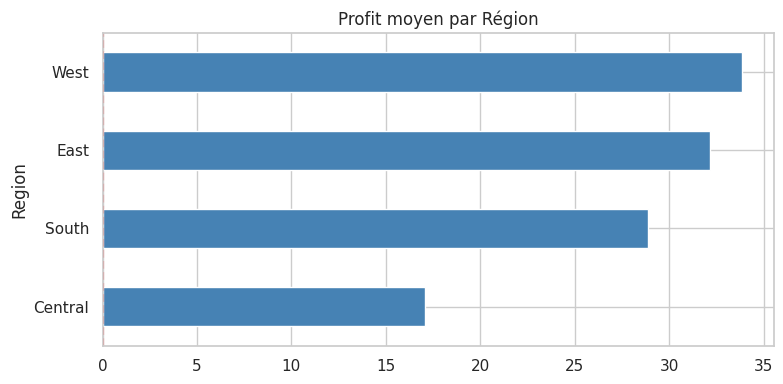

In [9]:
region_stats = df.groupby('Region').agg(
    profit_moyen=('Profit', 'mean'),
    taux_rentable=('Profit', lambda x: (x > 0).mean() * 100),
    ventes_totales=('Sales', 'sum')
).round(2)

print(region_stats.sort_values('profit_moyen', ascending=False))

region_stats['profit_moyen'].sort_values().plot(
    kind='barh', color='steelblue', figsize=(8,4)
)
plt.axvline(0, color='red', linestyle='--')
plt.title('Profit moyen par Région')
plt.tight_layout()
plt.savefig('fig5_profit_by_region.png', dpi=150)
plt.show()

/tmp/ipykernel_4183/4175476547.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('discount_bin')['Profit'].mean()


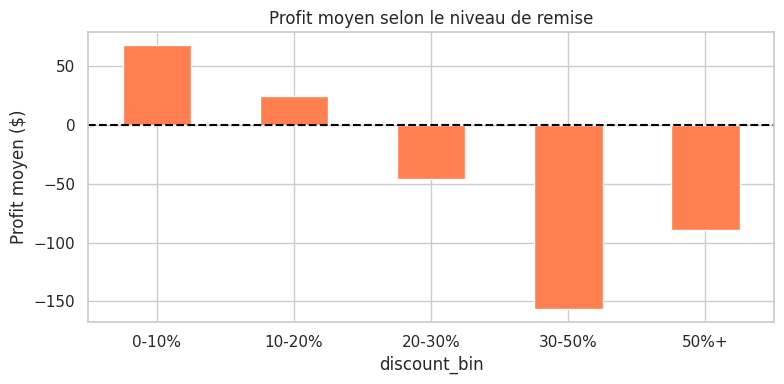

In [10]:
# Les remises élevées tuent la rentabilité — c'est l'insight le plus puissant du dataset
df['discount_bin'] = pd.cut(df['Discount'],
                             bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                             labels=['0-10%','10-20%','20-30%','30-50%','50%+'],
                             include_lowest=True)

discount_profit = df.groupby('discount_bin')['Profit'].mean()

discount_profit.plot(kind='bar', color='coral', figsize=(8,4))
plt.axhline(0, color='black', linestyle='--')
plt.title('Profit moyen selon le niveau de remise')
plt.ylabel('Profit moyen ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig6_discount_impact.png', dpi=150)
plt.show()

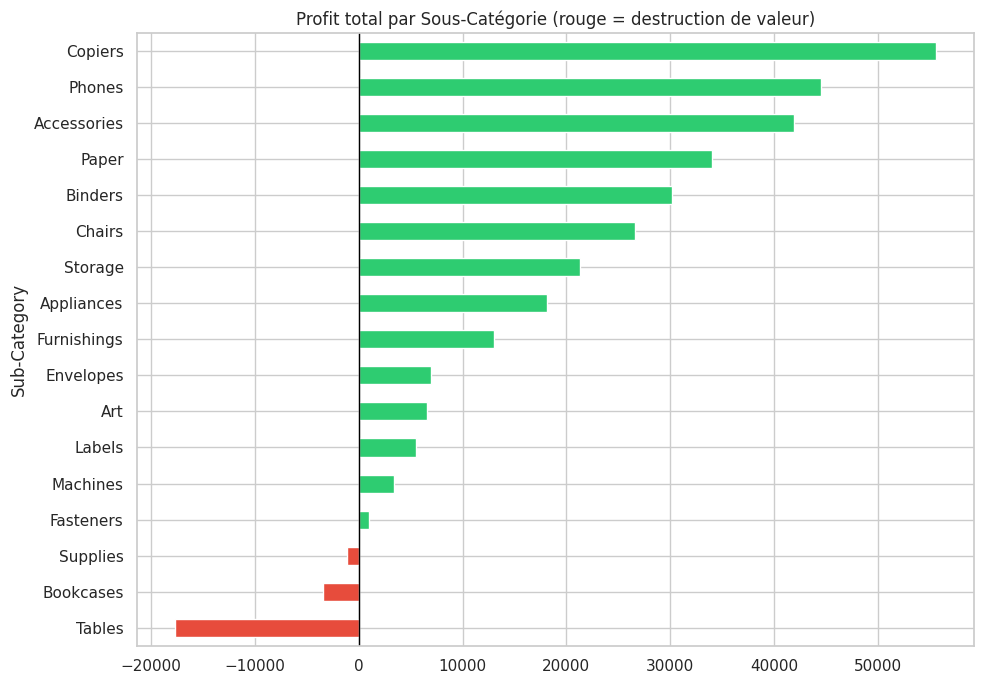

In [11]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in subcat_profit]
subcat_profit.plot(kind='barh', color=colors, figsize=(10, 7))
plt.axvline(0, color='black', linewidth=1)
plt.title('Profit total par Sous-Catégorie (rouge = destruction de valeur)')
plt.tight_layout()
plt.savefig('fig7_subcat_profit.png', dpi=150)
plt.show()

## Synthèse EDA

**1. Problèmes identifiés dans les données :**
- **Valeurs manquantes :** Aucune valeur manquante n'a été identifiée dans le jeu de données.
- **Outliers sur Sales :** La distribution des ventes est fortement asymétrique et présente des valeurs extrêmes (outliers), comme le montre la comparaison de la distribution brute et log-transformée. Une transformation logarithmique (log1p) est appropriée pour normaliser cette variable si elle était directement une cible de régression.
- **Colonnes potentiellement inutiles pour la modélisation directe :** Des colonnes comme 'Row ID', 'Order ID', 'Customer ID', 'Product ID', 'Customer Name', 'Product Name' sont des identifiants ou des descriptions textuelles et pourraient ne pas être directement utiles comme features numériques sans ingénierie de fonctionnalités.

**2. Features potentiellement utiles pour prédire la rentabilité (`is_profitable`) :**
- **Variables numériques :** 'Sales', 'Quantity', 'Discount', 'Profit' (bien que 'Profit' soit directement lié à la cible, 'Sales', 'Quantity', 'Discount' sont des prédicteurs).
- **Variables catégorielles :** 'Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category'. Les analyses ont déjà montré l'impact de 'Category', 'Region' et 'Sub-Category' sur le profit.
- **Variables temporelles :** 'Order Date', 'Ship Date' peuvent être utilisées pour extraire des features comme le jour de la semaine, le mois, le délai de livraison, etc.

**3. Transformations nécessaires avant modélisation :**
- **Encodage des colonnes catégorielles :** Les colonnes 'Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category' devront être encodées (par exemple, One-Hot Encoding ou Target Encoding) pour être utilisées dans les modèles de Machine Learning.
- **Transformation des dates :** Les colonnes 'Order Date' et 'Ship Date' devront être converties en format datetime et potentiellement utilisées pour créer de nouvelles features temporelles.

## Cadrage du Projet

**Problème métier :** Identifier les transactions à risque de perte avant leur conclusion, pour guider les décisions commerciales.

**Type de problème ML :** Classification binaire
**Variable cible :** `is_profitable` (1 si Profit > 0, 0 sinon)

**Métriques ML :** F1-Score (principal), ROC-AUC, Précision, Rappel

**KPIs business :**
- **Réduction du pourcentage de transactions non rentables :** L'objectif est de minimiser la proportion de ventes entraînant une perte.
- **Augmentation du profit moyen par transaction :** En identifiant et en ajustant les stratégies pour les transactions à risque.
- **Optimisation des stratégies de remise :** Cibler les remises pour éviter les pertes, en particulier pour les remises > 20%.
- **Amélioration de la rentabilité par catégorie et région :** Mettre l'accent sur les catégories et régions les moins performantes.

**Insights EDA :**
- **Catégories :**
    - La catégorie 'Furniture' affiche le profit moyen le plus bas et le pourcentage le plus faible de transactions rentables (environ 64%).
    - Les 'Office Supplies' et 'Technology' sont plus rentables, avec un taux de transactions rentables autour de 85%.
    - Certaines sous-catégories (ex: Tables, Bookcases) sont significativement non rentables.
- **Régions :**
    - Les régions 'West' et 'East' sont les plus performantes en termes de profit moyen et de taux de rentabilité.
    - La région 'Central' est la moins performante, avec le profit moyen le plus bas et le taux de transactions rentables le plus faible (67.63%).
- **Remises :**
    - Les remises supérieures à 20% entraînent systématiquement une perte moyenne par transaction.
    - Les remises entre 0-10% et 10-20% sont associées à des profits moyens positifs.